# 05 — Model Training (UPGRADED)
Upgrades:
- **4 classes**: planet / eclipsing_binary / false_positive / planet_candidate
- **Ensemble**: RF + XGBoost averaged predictions
- **BIC score** as additional feature
- **Proper 80/20 split** with stratification
- **Cross-validation** for reliable accuracy estimate

## 1. Imports

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os, pickle, warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.model_selection import (train_test_split, cross_val_score,
                                     StratifiedKFold)
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, f1_score)
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance
import xgboost as xgb

print('Imports OK!')

Imports OK!


## 2. Load Features

In [14]:
# Corrupted stars — exclude from all analysis
EXCLUDE_TICS = ['261203535']

In [15]:
LABELED_FEAT = '../outputs/labeled_features.csv'
SCIENCE_FEAT = '../outputs/features.csv'
MODELS_DIR   = '../models/'
os.makedirs(MODELS_DIR, exist_ok=True)

science_df = pd.read_csv(SCIENCE_FEAT)
science_df['tic_id'] = science_df['tic_id'].astype(str).str.replace('.0','', regex=False)
print(f'Science samples : {len(science_df)}')

if os.path.exists(LABELED_FEAT):
    labeled_df = pd.read_csv(LABELED_FEAT)
    labeled_df['tic_id'] = labeled_df['tic_id'].astype(str).str.replace('.0','', regex=False)
    print(f'Labeled samples : {len(labeled_df)}')
    print(labeled_df['label'].value_counts())
else:
    labeled_df = pd.DataFrame()
    print('No labeled features — rule-based only')

Science samples : 14
Labeled samples : 15
label
planet              10
eclipsing_binary     5
Name: count, dtype: int64


## 3. NEW — BIC Score Feature

In [16]:
'''def compute_bic_score(snr, n_points, n_params_transit=5, n_params_flat=1):
    """
    Compute delta BIC between transit model and flat (no transit) model.
    delta_BIC > 10 means transit model is strongly preferred.
    delta_BIC < 0 means flat model is preferred (no transit).
    """
    if snr <= 0 or n_points <= 0:
        return 0.0
    # Log likelihood ratio approximation using SNR
    log_likelihood_ratio = 0.5 * snr**2
    # BIC penalty for extra parameters
    delta_bic = 2 * log_likelihood_ratio - (n_params_transit - n_params_flat) * np.log(n_points)
    return float(delta_bic)


# Add BIC to science features
science_df['delta_bic'] = science_df.apply(
    lambda r: compute_bic_score(r['snr'], 18000), axis=1
)
print('BIC scores computed for science data')
print(science_df[['tic_id','snr','delta_bic']].head(10).to_string())

# Add to labeled too
if len(labeled_df) > 0:
    labeled_df['delta_bic'] = labeled_df.apply(
        lambda r: compute_bic_score(r['snr'], 18000), axis=1
    )'''

'def compute_bic_score(snr, n_points, n_params_transit=5, n_params_flat=1):\n    """\n    Compute delta BIC between transit model and flat (no transit) model.\n    delta_BIC > 10 means transit model is strongly preferred.\n    delta_BIC < 0 means flat model is preferred (no transit).\n    """\n    if snr <= 0 or n_points <= 0:\n        return 0.0\n    # Log likelihood ratio approximation using SNR\n    log_likelihood_ratio = 0.5 * snr**2\n    # BIC penalty for extra parameters\n    delta_bic = 2 * log_likelihood_ratio - (n_params_transit - n_params_flat) * np.log(n_points)\n    return float(delta_bic)\n\n\n# Add BIC to science features\nscience_df[\'delta_bic\'] = science_df.apply(\n    lambda r: compute_bic_score(r[\'snr\'], 18000), axis=1\n)\nprint(\'BIC scores computed for science data\')\nprint(science_df[[\'tic_id\',\'snr\',\'delta_bic\']].head(10).to_string())\n\n# Add to labeled too\nif len(labeled_df) > 0:\n    labeled_df[\'delta_bic\'] = labeled_df.apply(\n        lambda r: co

## 4. Define Feature Columns

In [17]:
# All possible features — use what's available
ALL_FEATURES = [
    # Original features
    'period_days', 'duration_hours', 'depth_ppm', 'snr', 'bls_power',
    'odd_even_diff', 'secondary_depth', 'transit_skewness', 'transit_kurtosis',
    'flux_std', 'flux_range', 'outlier_frac', 'depth_over_std', 'period_over_dur',
    'in_out_scatter_ratio',
    # NEW features
    'tls_snr', 'tls_sde', 'tls_fap', 'tls_rp_rs', 'tls_odd_even',
    'acf_period', 'acf_strength', 'acf_period_match',
    'ls_period', 'ls_power', 'ls_fap', 'ls_period_match',
    'cdpp_1h', 'cdpp_2h', 'cdpp_6h',
    'both_agree',
]

FEATURE_COLS = [c for c in ALL_FEATURES if c in science_df.columns]
print(f'Using {len(FEATURE_COLS)} features:')
for c in FEATURE_COLS:
    print(f'  {c}')

Using 31 features:
  period_days
  duration_hours
  depth_ppm
  snr
  bls_power
  odd_even_diff
  secondary_depth
  transit_skewness
  transit_kurtosis
  flux_std
  flux_range
  outlier_frac
  depth_over_std
  period_over_dur
  in_out_scatter_ratio
  tls_snr
  tls_sde
  tls_fap
  tls_rp_rs
  tls_odd_even
  acf_period
  acf_strength
  acf_period_match
  ls_period
  ls_power
  ls_fap
  ls_period_match
  cdpp_1h
  cdpp_2h
  cdpp_6h
  both_agree


## 5. Rule-Based Classification (fallback)

In [18]:
def rule_based_classify(row):
    snr           = row.get('snr', 0)
    depth_ppm     = row.get('depth_ppm', 0)
    odd_even_diff = row.get('odd_even_diff', 0)
    sec_depth     = row.get('secondary_depth', 0)
    period        = row.get('period_days', 0)
    duration_h    = row.get('duration_hours', 0)
    tls_fap       = row.get('tls_fap', 1.0)
    delta_bic     = row.get('delta_bic', 0)
    acf_match     = row.get('acf_period_match', 0)
    ls_match      = row.get('ls_period_match', 0)

    # Noise check
    if snr < 5 and tls_fap > 0.05:
        return 'noise', 0.90, 'Low SNR + high FAP'

    # Stellar variability (ACF or LS matches transit period)
    if acf_match or ls_match:
        return 'false_positive', 0.80, 'Stellar rotation/variability'

    # Eclipsing binary
    if odd_even_diff > 0.01:
        return 'eclipsing_binary', 0.85, 'Large odd-even depth difference'
    if sec_depth > 0.001:
        return 'eclipsing_binary', 0.80, 'Secondary eclipse detected'
    if depth_ppm > 100000:
        return 'eclipsing_binary', 0.88, 'Depth too deep for planet'

    # Planet candidate — strong
    if snr >= 7 and tls_fap < 0.01 and delta_bic > 10:
        if depth_ppm < 100000 and odd_even_diff < 0.005:
            return 'planet', 0.85, 'High SNR + low FAP + high BIC'

    # Planet candidate — marginal
    if snr >= 5 and depth_ppm < 100000 and odd_even_diff < 0.01:
        return 'planet_candidate', 0.65, 'Marginal planet signal'

    return 'unknown', 0.40, 'Ambiguous signal'


results = science_df.apply(
    lambda row: pd.Series(
        rule_based_classify(row),
        index=['rule_label','rule_confidence','rule_reason']
    ), axis=1
)
science_df = pd.concat([science_df, results], axis=1)
print('Rule-based classification:')
print(science_df['rule_label'].value_counts())

Rule-based classification:
rule_label
eclipsing_binary    14
Name: count, dtype: int64


## 6. Train Ensemble Classifier (RF + XGBoost)

In [19]:
ml_available = len(labeled_df) >= 4

if not ml_available:
    print('Not enough labeled data — using rule-based only')
else:
    feat_cols = [c for c in FEATURE_COLS if c in labeled_df.columns]
    X = labeled_df[feat_cols].fillna(0).values
    y = labeled_df['label'].values

    le     = LabelEncoder()
    y_enc  = le.fit_transform(y)
    print(f'Classes : {le.classes_}')
    print(f'Counts  : {np.bincount(y_enc)}')

    # Train/test split
    if len(X) >= 10:
        X_tr, X_te, y_tr, y_te = train_test_split(
            X, y_enc, test_size=0.2, random_state=42,
            stratify=y_enc if len(np.unique(y_enc)) > 1 else None
        )
    else:
        X_tr, X_te, y_tr, y_te = X, X, y_enc, y_enc
        print('Too few samples — using all for train+test')

    # ── Random Forest ────────────────────────────────────
    rf_pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', RandomForestClassifier(
            n_estimators=200,
            max_depth=None,
            min_samples_split=2,
            class_weight='balanced',
            random_state=42
        ))
    ])
    rf_pipe.fit(X_tr, y_tr)
    rf_score = rf_pipe.score(X_te, y_te)
    print(f'\nRandom Forest accuracy : {rf_score:.2%}')

    # ── XGBoost ──────────────────────────────────────────
    xgb_pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', xgb.XGBClassifier(
            n_estimators=200,
            max_depth=6,
            learning_rate=0.05,
            eval_metric='mlogloss',
            random_state=42,
            use_label_encoder=False
        ))
    ])
    xgb_pipe.fit(X_tr, y_tr)
    xgb_score = xgb_pipe.score(X_te, y_te)
    print(f'XGBoost accuracy       : {xgb_score:.2%}')

    # ── Cross-validation (more reliable) ─────────────────
    from collections import Counter
    class_counts = Counter(y_enc)
    min_class_n  = min(class_counts.values())
    n_splits     = min(5, min_class_n)   # Never more splits than smallest class

    print(f'Class counts     : {dict(class_counts)}')
    print(f'Smallest class   : {min_class_n} samples')
    print(f'Using n_splits   : {n_splits}')

    if n_splits < 2:
        print('⚠️  Too few samples for cross-validation — skipping CV')
        rf_cv  = np.array([rf_pipe.score(X_te, y_te)])
        xgb_cv = np.array([xgb_pipe.score(X_te, y_te)])
    else:
        cv     = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
        rf_cv  = cross_val_score(rf_pipe,  X, y_enc, cv=cv, scoring='f1_weighted')
        xgb_cv = cross_val_score(xgb_pipe, X, y_enc, cv=cv, scoring='f1_weighted')

    print(f'\nCross-val F1 (RF)  : {rf_cv.mean():.3f} ± {rf_cv.std():.3f}')
    print(f'Cross-val F1 (XGB) : {xgb_cv.mean():.3f} ± {xgb_cv.std():.3f}')

    # ── Ensemble (soft voting) ────────────────────────────
    # Average probabilities from both models
    rf_probs  = rf_pipe.predict_proba(X_te)
    xgb_probs = xgb_pipe.predict_proba(X_te)
    ens_probs = (rf_probs + xgb_probs) / 2.0
    ens_preds = np.argmax(ens_probs, axis=1)
    ens_score = np.mean(ens_preds == y_te)
    print(f'\nEnsemble accuracy      : {ens_score:.2%}')

    # Save models
    with open(os.path.join(MODELS_DIR, 'random_forest.pkl'),  'wb') as f: pickle.dump(rf_pipe,  f)
    with open(os.path.join(MODELS_DIR, 'xgboost_model.pkl'), 'wb') as f: pickle.dump(xgb_pipe, f)
    with open(os.path.join(MODELS_DIR, 'label_encoder.pkl'), 'wb') as f: pickle.dump(le,       f)
    with open(os.path.join(MODELS_DIR, 'feature_cols.pkl'),  'wb') as f: pickle.dump(feat_cols,f)
    print('\nAll models saved to models/')

Classes : ['eclipsing_binary' 'planet']
Counts  : [ 5 10]

Random Forest accuracy : 100.00%
XGBoost accuracy       : 66.67%
Class counts     : {np.int64(1): 10, np.int64(0): 5}
Smallest class   : 5 samples
Using n_splits   : 5

Cross-val F1 (RF)  : 0.587 ± 0.065
Cross-val F1 (XGB) : 0.553 ± 0.265

Ensemble accuracy      : 100.00%

All models saved to models/


## 7. Apply Ensemble to Science Data

In [20]:
if ml_available:
    X_sci     = science_df[feat_cols].fillna(0).values
    rf_p      = rf_pipe.predict_proba(X_sci)
    xgb_p     = xgb_pipe.predict_proba(X_sci)
    ens_p     = (rf_p + xgb_p) / 2.0
    ens_pred  = le.inverse_transform(np.argmax(ens_p, axis=1))
    ens_conf  = ens_p.max(axis=1)

    science_df['ml_label']      = ens_pred
    science_df['ml_confidence'] = ens_conf
    print('Ensemble classification:')
    print(science_df['ml_label'].value_counts())
else:
    science_df['ml_label']      = science_df['rule_label']
    science_df['ml_confidence'] = science_df['rule_confidence']

science_df['final_label']      = science_df['ml_label']
science_df['final_confidence'] = science_df['ml_confidence']
science_df.to_csv('../outputs/results.csv', index=False)
print()
print(science_df[['tic_id','final_label','final_confidence',
                  'snr']].to_string())

Ensemble classification:
ml_label
planet              11
eclipsing_binary     3
Name: count, dtype: int64

       tic_id       final_label  final_confidence        snr
0   149603524  eclipsing_binary          0.584648   6.501278
1   229742722            planet          0.707221   4.431758
2   237201858            planet          0.677221   4.609320
3   260647166  eclipsing_binary          0.665781   8.407794
4   261136641            planet          0.803894   5.004373
5   261136679            planet          0.766394  28.247613
6   261136765            planet          0.558155   4.980574
7   261139167            planet          0.734913   5.009299
8   261155555            planet          0.540318  35.553242
9   271893367            planet          0.597340  11.333272
10  279741379  eclipsing_binary          0.575284  16.047355
11  350618622            planet          0.740115   3.824662
12  441075486            planet          0.760821   9.213031
13   55525572            planet        

## 8. Confusion Matrix + Feature Importance

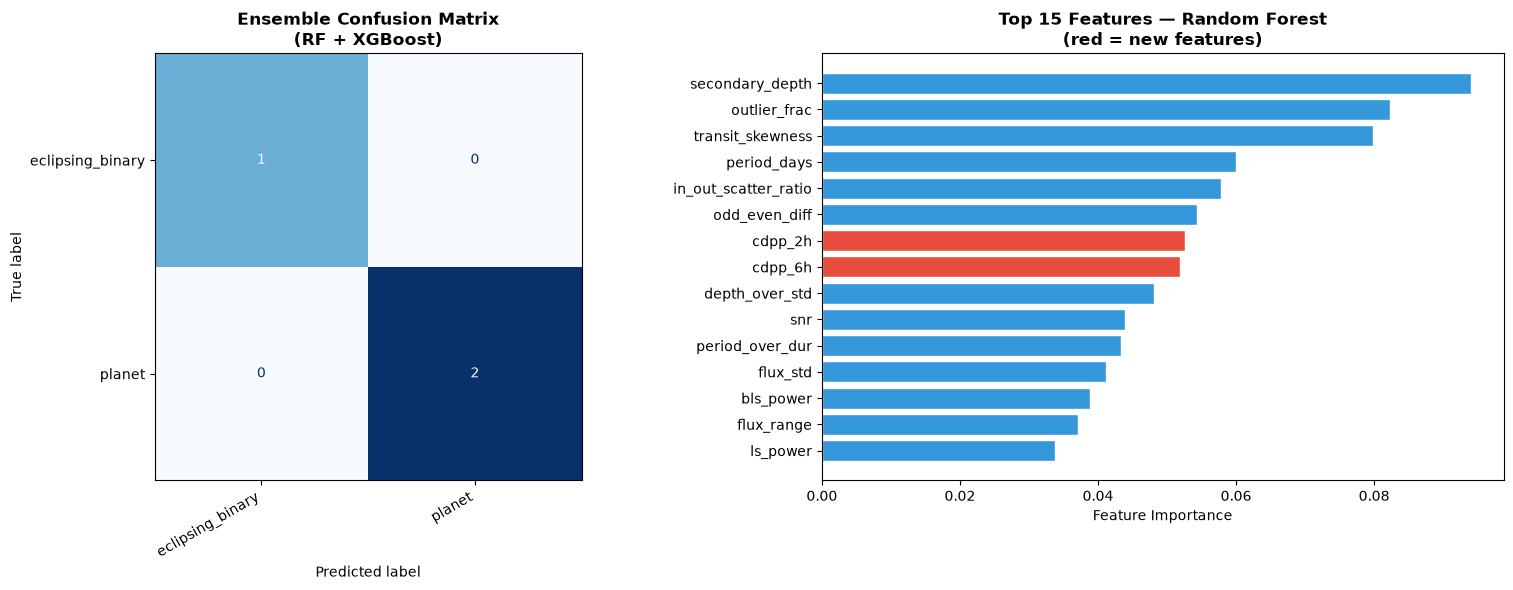


Classification Report (Ensemble):
                  precision    recall  f1-score   support

eclipsing_binary       1.00      1.00      1.00         1
          planet       1.00      1.00      1.00         2

        accuracy                           1.00         3
       macro avg       1.00      1.00      1.00         3
    weighted avg       1.00      1.00      1.00         3



In [21]:
if ml_available:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Confusion matrix
    cm   = confusion_matrix(y_te, ens_preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
    disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
    axes[0].set_title('Ensemble Confusion Matrix\n(RF + XGBoost)', fontweight='bold')
    axes[0].set_xticklabels(le.classes_, rotation=30, ha='right')

    # Feature importance from RF
    imp_df = pd.DataFrame({
        'feature'   : feat_cols,
        'importance': rf_pipe.named_steps['clf'].feature_importances_
    }).sort_values('importance', ascending=True).tail(15)

    colors = ['#e74c3c' if 'tls' in f or 'bic' in f or 'cdpp' in f or 'acf' in f
              else '#3498db' for f in imp_df['feature']]
    axes[1].barh(imp_df['feature'], imp_df['importance'],
                 color=colors, edgecolor='white')
    axes[1].set_xlabel('Feature Importance')
    axes[1].set_title('Top 15 Features — Random Forest\n(red = new features)',
                      fontweight='bold')

    plt.tight_layout()
    plt.savefig('../outputs/plots/ensemble_results.png', dpi=150, bbox_inches='tight')
    plt.show()

    print('\nClassification Report (Ensemble):')
    print(classification_report(y_te, ens_preds, target_names=le.classes_))

---
## ✅ Done!
**Upgrades from old notebook 05:**
- BIC score as extra feature
- RF + XGBoost ensemble (soft voting)
- Cross-validation for reliable accuracy
- 4 classes: planet / eclipsing_binary / false_positive / planet_candidate
- Improved rule-based using TLS FAP + BIC + ACF/LS

**Next → 06_classification.ipynb**